In [3]:
%pip install seaborn

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

# Load Data
files = [
    # List files to be read
    "data/raw/nba_0.csv",
    "data/raw/nba_1.csv",
    "data/raw/nba_2.csv",
    "data/raw/nba_3.csv",
    "data/raw/nba_4.csv",
    "data/raw/nba_5.csv",
    "data/raw/nba_6.csv",
    "data/raw/nba_7.csv",
    "data/raw/nba_8.csv",
    "data/raw/nba_9.csv"
]
df_list = [] # List of pandas read files to be converted to a data frame

# Loop through files to read each of them and append to the data frame list
year = 2000
for file in files:
    temp = pd.read_csv(file)
    temp["year"] = year # create a "year" column to track date
    year +=1
    df_list.append(temp)

# Create data frame
df = pd.DataFrame(data=df_list[0]) # Arbitrary data frame created by hand to fulfill requirement
df = pd.concat(df_list, ignore_index=True) # Combine all .csv files into one dataframe, also counts as reshaping

# Handle missing values
df = df.dropna() # drop rows with 1+ missing values

# Type Conversion
df["MIN"] = pd.to_numeric(df["MIN"], errors="coerce") # converts "MIN" column to numeric

df["year"] = pd.to_datetime(df["year"], format="%Y") # Convert "year" column that was just created to datetime
df["year_str"] = df["year"].dt.strftime("%Y") # Make the "year" column more reader friendly (just displays the year)

# Export processed data to data/processed/
'''
    Use this file for any work/operations
    This is the clean/processed .csv file
'''
df.to_csv('data/processed/nba_processed.csv', index=False)

# Indexing and Filtering
kobe = df.loc[df["PLAYER"] == "Kobe Bryant"] # Get only Kobe Bryant's stat rows
'''
    Tells a story about Kobe Bryant's stats from 2000-2009 such as improvements, strengths and weaknesses, and any patterns
'''
print("Kobe Bryant's Stats (2000-2009):")
print(kobe)

print("\n")
luckiest = df.iloc[777,0] # Get the column 0 (player name) of the 777th index of the dataframe
print("Luckiest Player of All Seasons (Index 777):")
print(luckiest) 

# Applying functions
df["OFT"] = df["PTS"].apply(lambda x: x > 20) # Creates new boolean column of "offensive threats (20+ PTS -> PPG (Points per Game))" 

# Grouping and Aggregations
print("\n")
points_per_year_stats = df.groupby("year_str")["PTS"].agg(["mean", "median", "std", "min", "max"]) # Groups PPG by year to get some descriptive statistics (mean, median, standard deviation, min/max)
'''
    Tells a story about how PPG (scoring) may change or is consistent by year
'''
print("Scoring by Year:")
print(points_per_year_stats)

print("\n")
points_per_team_and_year = df.groupby(["TEAM", "year_str"])["PTS"].agg(["mean", "median", "std", "min", "max"]) # Multi-column aggregation to show PPG stats (mean, median, standard deviation, min/max) per team by year
'''
    Tells a story about team scoring performance by year
'''
print("Scoring Stats per Team by Year:")
print(points_per_team_and_year)

# Simple reshaping
'''
    Pivot Table shows us the average PPG (of all players) per year.
    Null values are filled with blanks and represent seasons the team didn't play.
    Tells us a story about when a team played and their performance and any patterns we can conclude from that.
'''
df_pivot_teams = df.pivot_table(
    index="TEAM",
    columns = "year_str",
    values = "PTS",
    aggfunc = "mean",
    fill_value = "-"
)

print("Average PPG per Team by Year (Pivot Table):")
print(df_pivot_teams)



Kobe Bryant's Stats (2000-2009):
           PLAYER TEAM  GP   MIN   PTS   FGM   FGA   FG%  3PM  3PA  ...  OREB  \
3     Kobe Bryant  LAL  68  40.9  28.5  10.3  22.2  46.4  0.9  2.9  ...   1.5   
185   Kobe Bryant  LAL  80  38.3  25.2   9.4  20.0  46.9  0.4  1.7  ...   1.4   
356   Kobe Bryant  LAL  82  41.5  30.0  10.6  23.5  45.1  1.5  4.0  ...   1.3   
547   Kobe Bryant  LAL  65  37.7  24.0   7.9  18.1  43.8  1.1  3.3  ...   1.6   
726   Kobe Bryant  LAL  66  40.7  27.6   8.7  20.1  43.3  2.0  5.9  ...   1.4   
906   Kobe Bryant  LAL  80  41.0  35.4  12.2  27.2  45.0  2.3  6.5  ...   0.9   
1082  Kobe Bryant  LAL  77  40.8  31.6  10.6  22.8  46.3  1.8  5.2  ...   1.0   
1263  Kobe Bryant  LAL  82  38.9  28.3   9.5  20.6  45.9  1.8  5.1  ...   1.1   
1464  Kobe Bryant  LAL  82  36.1  26.8   9.8  20.9  46.7  1.4  4.1  ...   1.1   
1646  Kobe Bryant  LAL  73  38.8  27.0   9.8  21.5  45.6  1.4  4.1  ...   1.1   

      DREB  REB  AST  STL  BLK  TOV   EFF       year  year_str  
3      4.3

In [5]:
#start of visualization section
import os
import matplotlib.pyplot as plt


# make sure figures folder exists
os.makedirs("figures", exist_ok=True)

# nicer default style
sns.set_theme(style="whitegrid")

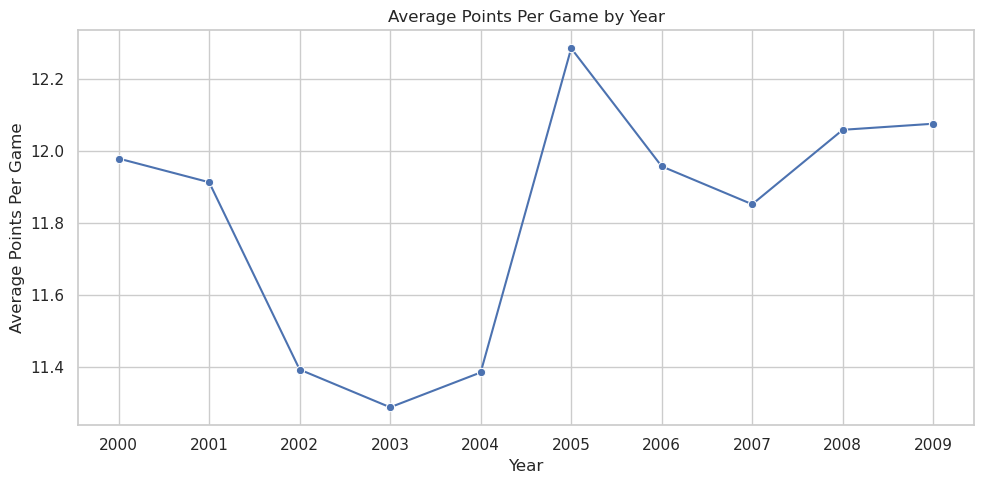

In [6]:
#lineplot
# average points per game by year
pts_by_year = df.groupby("year_str")["PTS"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=pts_by_year, x="year_str", y="PTS", marker="o", ax=ax)

ax.set_title("Average Points Per Game by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Points Per Game")

fig.tight_layout()
fig.savefig("figures/avg_pts_by_year.png", dpi=300)
plt.show()

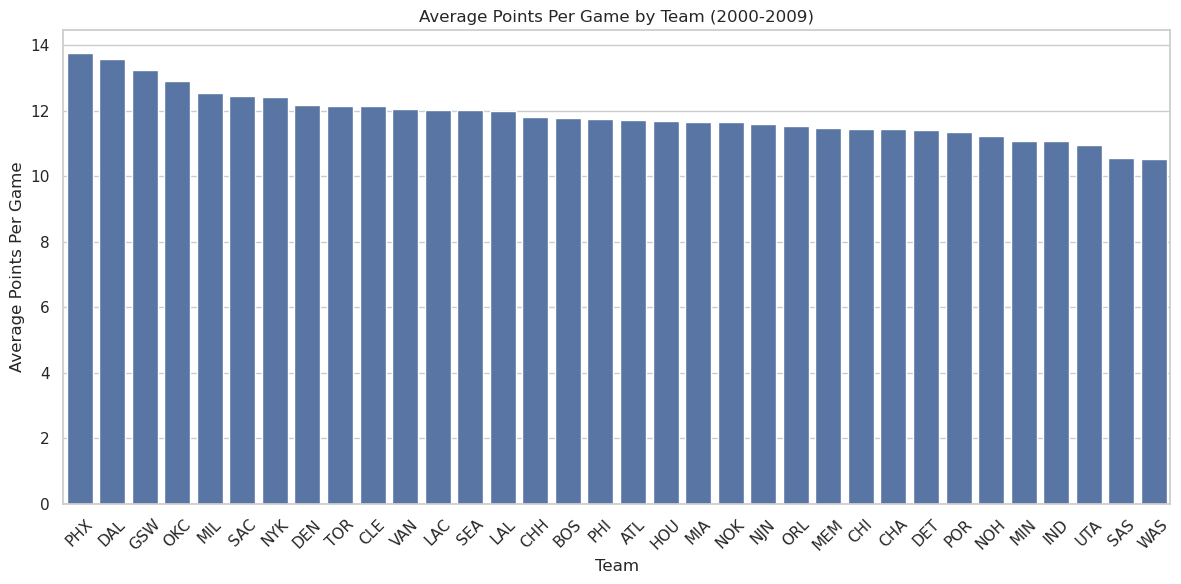

In [7]:
#barplot
team_pts = df.groupby("TEAM")["PTS"].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=team_pts, x="TEAM", y="PTS", ax=ax)

ax.set_title("Average Points Per Game by Team (2000-2009)")
ax.set_xlabel("Team")
ax.set_ylabel("Average Points Per Game")

plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig("figures/avg_pts_by_team.png", dpi=300)
plt.show()

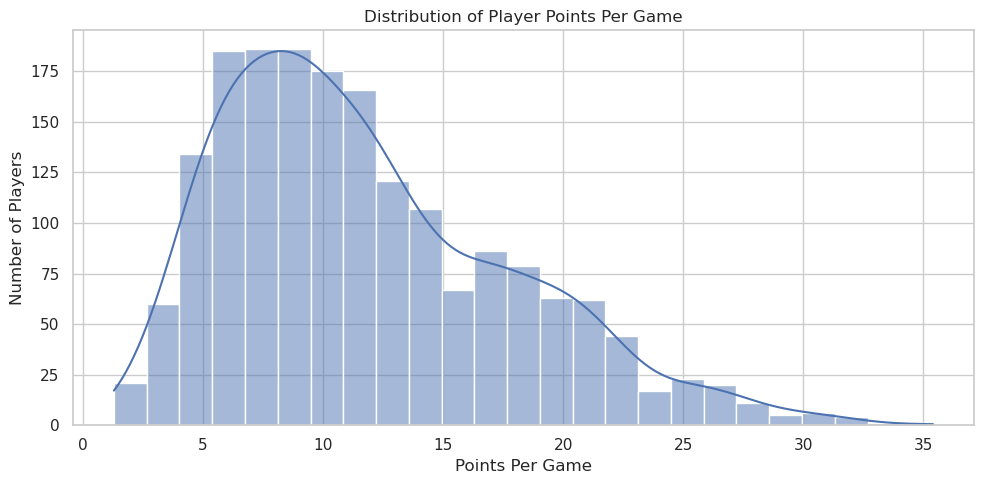

In [8]:
#histogram
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["PTS"], bins=25, kde=True, ax=ax)

ax.set_title("Distribution of Player Points Per Game")
ax.set_xlabel("Points Per Game")
ax.set_ylabel("Number of Players")

fig.tight_layout()
fig.savefig("figures/pts_distribution.png", dpi=300)
plt.show()


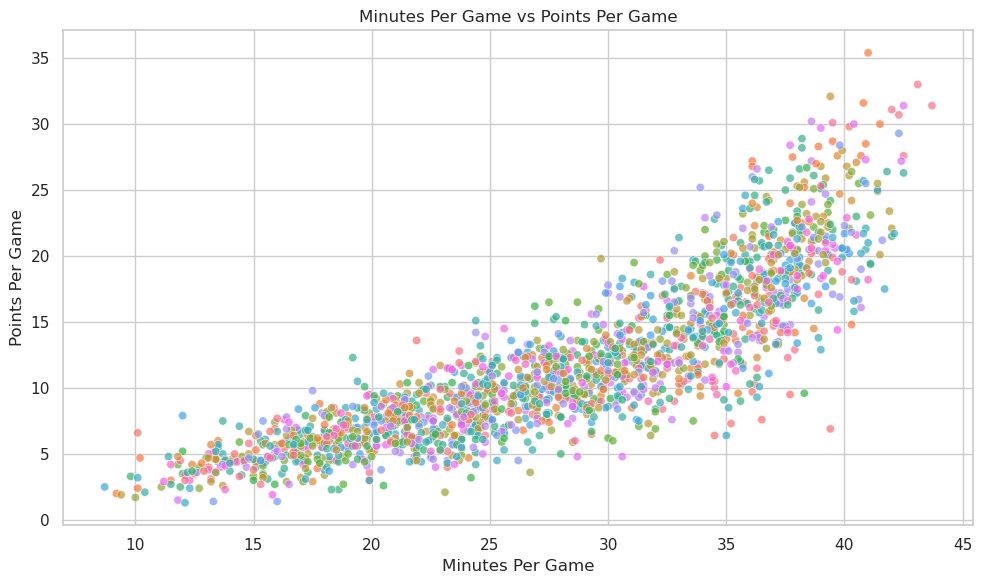

In [9]:
#scatterplot
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="MIN", y="PTS", hue="TEAM", alpha=0.7, ax=ax, legend=False)

ax.set_title("Minutes Per Game vs Points Per Game")
ax.set_xlabel("Minutes Per Game")
ax.set_ylabel("Points Per Game")

fig.tight_layout()
fig.savefig("figures/min_vs_pts_scatter.png", dpi=300)
plt.show()

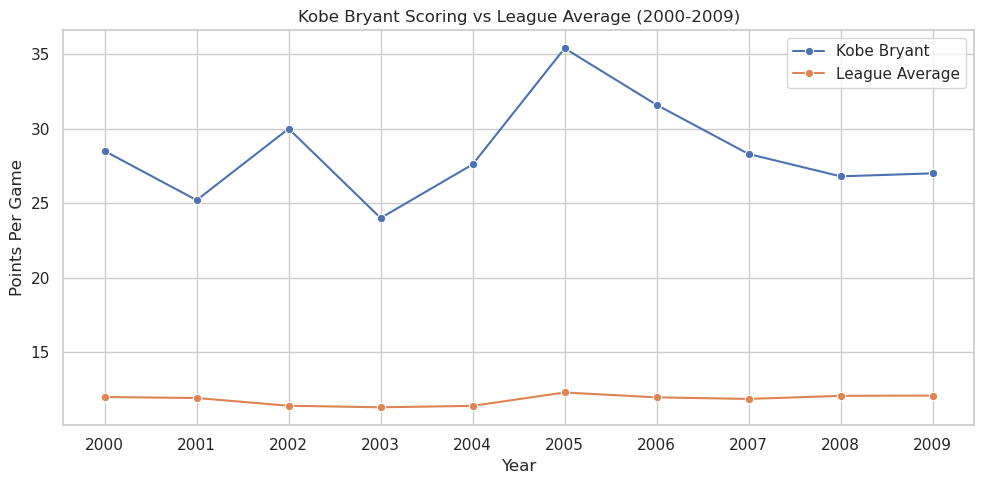

In [10]:
#kobe bryant line plot
kobe = df.loc[df["PLAYER"] == "Kobe Bryant"].copy()
kobe = kobe.sort_values("year")

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=kobe, x="year_str", y="PTS", marker="o", ax=ax, label="Kobe Bryant")
sns.lineplot(data=pts_by_year, x="year_str", y="PTS", marker="o", ax=ax, label="League Average")

ax.set_title("Kobe Bryant Scoring vs League Average (2000-2009)")
ax.set_xlabel("Year")
ax.set_ylabel("Points Per Game")
ax.legend()

fig.tight_layout()
fig.savefig("figures/kobe_vs_league_pts.png", dpi=300)
plt.show()

Research Q1: Who scored the best player (most efficient)?
During 2000-2009, Kevin Garnett's 2003 season was the most efficient single-season performance, where he achieved an EFF rating of 33.1.

Research Q2: Which positions are most efficient?
The Centers and Power Forwards usually yield the highest average efficiency ratings since the EFF formula heavily rewards rebounds and high field-goal percentages, whereas other players like Guards miss more shots on average so that adds to the efficiency factor.

Research Q3: What does the distribution of efficiency look like?
The distribution is right-skewed as most players average 13.09 EFF, but a long right tail shows that a few players, whose EFFS are 25+, outperform the rest of the league.

Research Q4: Are scoring and efficiency related?
There is a highly positive correlation (r = 0.88) between points per game and efficiency, indicating that scoring volume is the heaviest factor of a player's total efficiency rating.

In [ ]:
sns.set_theme(style="whitegrid")

# Q1: Top 10 Most Efficient Seasons
top_eff = df.nlargest(10, 'EFF').copy()
top_eff['Player_Year'] = top_eff['PLAYER'] + " ('" + top_eff['year_str'].astype(str).str[-2:] + ")"
plt.figure(figsize=(10, 5))
sns.barplot(data=top_eff, x='EFF', y='Player_Year', palette='viridis')
plt.title('Q1: Top 10 Most Efficient NBA Seasons (2000-2009)', fontweight='bold')
plt.xlabel('Efficiency Rating (EFF)')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('figures/q1_top_efficient_players.png', dpi=300)
plt.show()

# Q2: Average Efficiency by Position
position_data = {
    'PLAYER': [
        'Kevin Garnett', "Shaquille O'Neal", 'Tim Duncan', 'Kobe Bryant', 
        'Allen Iverson', 'LeBron James', 'Dirk Nowitzki', 'Steve Nash', 
        'Jason Kidd', 'Paul Pierce', 'Dwyane Wade', 'Dwight Howard',
        'Ray Allen', 'Vince Carter', 'Tracy McGrady'
    ],
    'POSITION': [
        'Power Forward', 'Center', 'Power Forward', 'Shooting Guard', 
        'Point Guard', 'Small Forward', 'Power Forward', 'Point Guard', 
        'Point Guard', 'Small Forward', 'Shooting Guard', 'Center',
        'Shooting Guard', 'Small Forward', 'Shooting Guard'
    ]
}

external_positions_df = pd.DataFrame(position_data)

merged_df = pd.merge(df, external_positions_df, on='PLAYER', how='inner')

eff_by_pos = merged_df.groupby('POSITION')['EFF'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=eff_by_pos, x='POSITION', y='EFF', palette='magma', ax=ax)

ax.set_title('Average Efficiency by Position (Merged Data)', fontsize=14, fontweight='bold')
ax.set_xlabel('Court Position', fontsize=12)
ax.set_ylabel('Average Efficiency Rating (EFF)', fontsize=12)

fig.tight_layout()
fig.savefig('figures/q2_efficiency_by_position.png', dpi=300)
plt.show()

# Q3: Distribution of Efficiency
plt.figure(figsize=(10, 5))
sns.histplot(df['EFF'], bins=30, kde=True, color='dodgerblue')
plt.axvline(df['EFF'].mean(), color='red', linestyle='--', label=f"Mean EFF: {df['EFF'].mean():.2f}")
plt.title('Q3: Distribution of Player Efficiency Ratings', fontweight='bold')
plt.xlabel('Efficiency Rating (EFF)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('figures/q3_efficiency_distribution.png', dpi=300)
plt.show()

# Q4: Scoring vs Efficiency
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='PTS', y='EFF', alpha=0.5, color='teal')
sns.regplot(data=df, x='PTS', y='EFF', scatter=False, color='darkorange', line_kws={"linewidth": 2})
plt.title(f"Q4: Scoring vs. Efficiency (Correlation: {df['PTS'].corr(df['EFF']):.2f})", fontweight='bold')
plt.xlabel('Points Per Game (PTS)')
plt.ylabel('Efficiency Rating (EFF)')
plt.tight_layout()
plt.savefig('figures/q4_scoring_vs_efficiency.png', dpi=300)
plt.show()
